In [1]:
%pip install langchain-google-genai


     ------------------------------------ 146.9/146.9 kB 976.2 kB/s eta 0:00:00
     -------------------------------------- 598.7/598.7 kB 3.4 MB/s eta 0:00:00
  Using cached google_auth-2.25.2-py2.py3-none-any.whl (184 kB)
  Using cached google_api_core-2.15.0-py3-none-any.whl (121 kB)
  Using cached protobuf-4.25.1-cp310-abi3-win_amd64.whl (413 kB)
  Using cached proto_plus-1.23.0-py3-none-any.whl (48 kB)
  Using cached googleapis_common_protos-1.62.0-py2.py3-none-any.whl (228 kB)
  Using cached cachetools-5.3.2-py3-none-any.whl (9.3 kB)
  Using cached pyasn1_modules-0.3.0-py2.py3-none-any.whl (181 kB)
  Using cached rsa-4.9-py3-none-any.whl (34 kB)
  Using cached grpcio-1.60.0-cp311-cp311-win_amd64.whl (3.7 MB)
  Using cached grpcio_status-1.60.0-py3-none-any.whl (14 kB)
  Using cached pyasn1-0.5.1-py2.py3-none-any.whl (84 kB)



[notice] A new release of pip available: 22.3.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

c:\Users\burha\Mentorskool\Self Learning\GenAI\Open Source Models\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

True

1. Langchain reference: https://python.langchain.com/docs/integrations/chat/google_generative_ai
2. Reference: https://console.cloud.google.com/apis/api/generativelanguage.googleapis.com/metrics?project=langchain-408712

In [4]:
llm = ChatGoogleGenerativeAI(google_api_key=os.environ.get("PALM_API_KEY"), model="gemini-pro")
result = llm.invoke("Write a ballad about LangChain")
print(result.content)

In the realm of AI, a tale unfolds,
Of LangChain's prowess, in verses untold.
A ballad of data and algorithms rare,
Unveiling the secrets that language can bear.

From vast troves of text, it sprang into life,
A model of language, both subtle and rife.
With layers of meaning, it delved deep,
Understanding nuances that others could keep.

Its vast neural network, a marvel to behold,
Connections intricate, stories yet untold.
It learned from the masters, from Shakespeare to Joyce,
Absorbing their styles, their cadence, their voice.

In prose and in verse, its words took flight,
Enchanting the world with its luminous light.
It spun tales of love and loss and despair,
With a beauty and grace that made hearts aware.

But LangChain's potential, it knew, was far more,
Than mere imitation, it yearned to explore.
New realms of language, it dared to create,
With words that shimmered and danced on the plate.

It dreamed of a world where language was free,
Where meaning could soar, like a bird on 

In [4]:
result = llm.invoke("Who is MS Dhoni?")
print(result.content)

Mahendra Singh Dhoni (born 7 July 1981), commonly known as MS Dhoni, is a former Indian cricketer who captained the Indian national team in limited-overs formats from 2007 to 2016 and in Test cricket from 2008 to 2014. He is considered one of the greatest finishers in limited-overs cricket and is widely regarded as one of the best wicket-keeper batsmen of all time.

Dhoni made his international debut in 2004 and quickly rose through the ranks to become one of the most consistent performers for India. He was a key member of the Indian team that won the 2007 ICC World Twenty20, the 2011 ICC Cricket World Cup and the 2013 ICC Champions Trophy. He also led India to victory in the 2010 Asia Cup and the 2016 Asia Cup.

Dhoni is known for his cool temperament, his quick reflexes behind the stumps, and his powerful hitting ability. He is also a very good reader of the game and is known for his ability to make quick decisions under pressure.

Dhoni retired from international cricket in 2020, bu

Gemini doesn’t support SystemMessage at the moment, but it can be added to the first human message in the row. If you want such behavior, just set the convert_system_message_to_human to True:

In [5]:
from langchain.schema.messages import HumanMessage, SystemMessage

model = ChatGoogleGenerativeAI(google_api_key=os.environ.get("GOOGLE_API_KEY"), model="gemini-pro", convert_system_message_to_human=True)
model(
    [
        SystemMessage(content="Answer only yes or no."),
        HumanMessage(content="Is apple a fruit?"),
    ]
)

AIMessage(content='Yes')

ChatGoogleGenerativeAI natively supports streaming and batching. Below is an example.

In [4]:
llm = ChatGoogleGenerativeAI(
    google_api_key=os.environ.get("GOOGLE_API_KEY"),
    model="gemini-pro"
)

In [7]:
for chunk in llm.stream("Write a limerick about LLMs."):
    print(chunk.content)
    print("---")
# Note that each chunk may contain more than one "token"

In a world where AIs excel,
There's a new kind of
---
 tool, they call LLMs.
They write and translate,
And summarize debate,
With creative flair, their talents swell.
---


In [9]:
llm.invoke("Who is the founder of Apple?")

AIMessage(content='Steve Jobs')

In [5]:
import requests
from IPython.display import Image

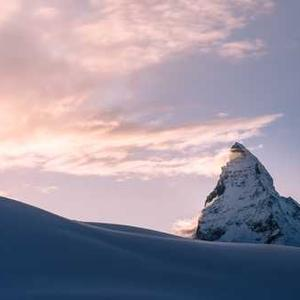

In [6]:
image_url = "https://picsum.photos/seed/picsum/300/300"
content = requests.get(image_url).content
Image(content)

In [12]:
%pip install langchain_core

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# PIL is required to load images
%pip install pillow

  Using cached Pillow-10.1.0-cp311-cp311-win_amd64.whl (2.6 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    google_api_key=os.environ.get("GOOGLE_API_KEY"),
    model="gemini-pro-vision"
    )

message = HumanMessage(
    content=[
        {
            "type": "text", 
            "text": "What's in this image?"
        },
        {"type": "image_url", "image_url": image_url}
    ],
)

In [11]:
llm.invoke([message])

AIMessage(content=' A snow-capped mountain peak at sunset.')

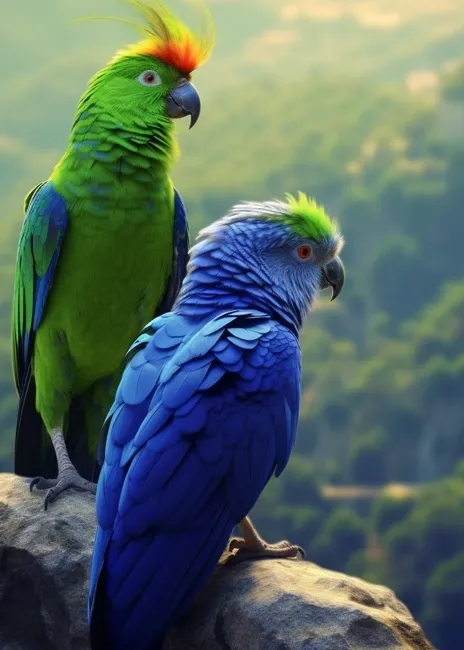

In [12]:
image_url = "https://imgupscaler.com/images/samples/animal-before.webp"
content = requests.get(image_url).content
Image(content)

In [13]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Describe the given image"
        },
        {
            "type": "image_url",
            "image_url": image_url
        }
    ]
)

In [14]:
llm.invoke([message])

AIMessage(content=' This is an image of two parrots sitting on a rock. The one on the left is green with a yellow head, and the one on the right is blue with a green head. The background is a blurred landscape of green trees and a blue sky.')

### SQL Challenger Bot

In [3]:
llm = ChatGoogleGenerativeAI(google_api_key=os.environ.get("PALM_API_KEY"), model="gemini-pro")

In [4]:
from langchain.prompts import PromptTemplate

template = """
    You are a good SQL challenger bot that provides different sql challenges to the users. Take the difficulty level
    from the user and based on that provide a single sql challenge with the database schema required for that challenge.

    Ex: Select the name of the employee and the department name where the employee has the most salary
    In this give the database schema of the table that we have to use to fetch the data from the table. Like 
    refer the employee table and department table to solve the given challenge. 
    The employee table contains the following attributes that is employee_id, employee_name, department_id, salary
    The department table contains the following attribute that is department_id, department_name
    
    
    It will help the user to write the proper sql query.

    Human: {difficulty_level}
    AI:
"""

In [5]:
prompt_template = PromptTemplate.from_template(
    template=template
)

In [6]:
from langchain.chains import LLMChain

chain = LLMChain(llm=llm, prompt=prompt_template)

In [7]:
result = chain.run(difficulty_level='Beginner')

"**Challenge:** Find the total sales for each product in a given category.\n\n**Database Schema:**\n\n```\nCREATE TABLE products (\n  product_id INT NOT NULL PRIMARY KEY,\n  product_name VARCHAR(255) NOT NULL,\n  category_id INT NOT NULL,\n  price DECIMAL(10, 2) NOT NULL,\n  quantity_in_stock INT NOT NULL\n);\n\nCREATE TABLE categories (\n  category_id INT NOT NULL PRIMARY KEY,\n  category_name VARCHAR(255) NOT NULL\n);\n\nCREATE TABLE sales (\n  sale_id INT NOT NULL PRIMARY KEY,\n  product_id INT NOT NULL,\n  quantity_sold INT NOT NULL,\n  sale_date DATE NOT NULL\n);\n```\n\n**Example Data:**\n\n```\nINSERT INTO categories (category_id, category_name) VALUES\n  (1, 'Electronics'),\n  (2, 'Clothing'),\n  (3, 'Home Goods');\n\nINSERT INTO products (product_id, product_name, category_id, price, quantity_in_stock) VALUES\n  (1, 'iPhone 13', 1, 999.99, 10),\n  (2, 'Samsung Galaxy S22', 1, 849.99, 15),\n  (3, 'Beats Studio3 Wireless Headphones', 1, 349.99, 20),\n  (4, 'Nike Air Force 1', 2,

In [9]:
print(result)

**Challenge:** Find the total sales for each product in a given category.

**Database Schema:**

```
CREATE TABLE products (
  product_id INT NOT NULL PRIMARY KEY,
  product_name VARCHAR(255) NOT NULL,
  category_id INT NOT NULL,
  price DECIMAL(10, 2) NOT NULL,
  quantity_in_stock INT NOT NULL
);

CREATE TABLE categories (
  category_id INT NOT NULL PRIMARY KEY,
  category_name VARCHAR(255) NOT NULL
);

CREATE TABLE sales (
  sale_id INT NOT NULL PRIMARY KEY,
  product_id INT NOT NULL,
  quantity_sold INT NOT NULL,
  sale_date DATE NOT NULL
);
```

**Example Data:**

```
INSERT INTO categories (category_id, category_name) VALUES
  (1, 'Electronics'),
  (2, 'Clothing'),
  (3, 'Home Goods');

INSERT INTO products (product_id, product_name, category_id, price, quantity_in_stock) VALUES
  (1, 'iPhone 13', 1, 999.99, 10),
  (2, 'Samsung Galaxy S22', 1, 849.99, 15),
  (3, 'Beats Studio3 Wireless Headphones', 1, 349.99, 20),
  (4, 'Nike Air Force 1', 2, 99.99, 30),
  (5, 'adidas Originals Su

**Challenge:** Find the total sales for each product in a given category.

**Database Schema:**

```
CREATE TABLE products (
  product_id INT NOT NULL PRIMARY KEY,
  product_name VARCHAR(255) NOT NULL,
  category_id INT NOT NULL,
  price DECIMAL(10, 2) NOT NULL,
  quantity_in_stock INT NOT NULL
);

CREATE TABLE categories (
  category_id INT NOT NULL PRIMARY KEY,
  category_name VARCHAR(255) NOT NULL
);

CREATE TABLE sales (
  sale_id INT NOT NULL PRIMARY KEY,
  product_id INT NOT NULL,
  quantity_sold INT NOT NULL,
  sale_date DATE NOT NULL
);
```

**Example Data:**

```
INSERT INTO categories (category_id, category_name) VALUES
  (1, 'Electronics'),
  (2, 'Clothing'),
  (3, 'Home Goods');

INSERT INTO products (product_id, product_name, category_id, price, quantity_in_stock) VALUES
  (1, 'iPhone 13', 1, 999.99, 10),
  (2, 'Samsung Galaxy S22', 1, 849.99, 15),
  (3, 'Beats Studio3 Wireless Headphones', 1, 349.99, 20),
  (4, 'Nike Air Force 1', 2, 99.99, 30),
  (5, 'adidas Originals Superstar', 2, 89.99, 25),
  (6, 'Levi''s 501 Original Jeans', 2, 69.99, 40),
  (7, 'KitchenAid Artisan Series Stand Mixer', 3, 399.99, 5),
  (8, 'Dyson V11 Animal Vacuum Cleaner', 3, 499.99, 3),
  (9, 'Ninja Foodi 10-in-1 Air Fryer', 3, 199.99, 10);

INSERT INTO sales (sale_id, product_id, quantity_sold, sale_date) VALUES
  (1, 1, 2, '2022-01-01'),
  (2, 2, 1, '2022-01-02'),
  (3, 3, 3, '2022-01-03'),
  (4, 4, 4, '2022-01-04'),
  (5, 5, 5, '2022-01-05'),
  (6, 6, 6, '2022-01-06'),
  (7, 7, 1, '2022-01-07'),
  (8, 8, 2, '2022-01-08'),
  (9, 9, 3, '2022-01-09');
```

**Query:**

```sql
SELECT
  c.category_name,
  p.product_name,
  SUM(s.quantity_sold * p.price) AS total_sales
FROM
  categories c
JOIN
  products p ON c.category_id = p.category_id
JOIN
  sales s ON p.product_id = s.product_id
GROUP BY
  c.category_name,
  p.product_name
ORDER BY
  total_sales DESC;
```

**Output:**

```
+----------------+--------------------+------------+
| category_name | product_name      | total_sales |
+----------------+--------------------+------------+
| Electronics   | iPhone 13         | 1999.98    |
| Electronics   | Samsung Galaxy S22 | 849.99     |
| Electronics   | Beats Studio3...  | 699.98     |
| Clothing      | Levi's 501...     | 2799.60    |
| Clothing      | adidas...         | 2249.75    |
| Clothing      | Nike Air Force 1  | 2999.76    |
| Home Goods    | Dyson V11...      | 999.98     |
| Home Goods    | KitchenAid...     | 399.99     |
| Home Goods    | Ninja Foodi...    | 599.97     |
+----------------+--------------------+------------+
```

Refer the above output. In this along with the Challenge and Database Schema, the SQL query is also provided. But the sql query we have to take from the user